## Data & AI 5/Artificial Intelligence: Machine Learning
## lifecycle Project
#### Team 30: Solovyova Aleksiya, Baldeva Vesela, Haazen Storm


### 1. Data Understanding and Exploration

##### Dataset: Mushroom  
##### Missing values: Yes
##### Description: This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended.  This latter class was combined with the poisonous one.  The Guide clearly states that there is no simple rule for determining the edibility of a mushroom; no rule like ``leaflets three, let it be'' for Poisonous Oak and Ivy.



#### Variables Table

| Variable Name | Role | Type | Description | Units | Missing Values |
|---|---|---|---|---|---|
| poisonous | Target | Categorical | | | no |
| cap-shape | Feature | Categorical | bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s | | no |
| cap-surface | Feature | Categorical | fibrous=f,grooves=g,scaly=y,smooth=s | | no |
| cap-color | Feature | Binary | brown=n,buff=b,cinnamon=c,gray=g,green=r, pink=p,purple=u,red=e,white=w,yellow=y | | no |
| bruises | Feature | Categorical | bruises=t,no=f | | no |
| odor | Feature | Categorical | almond=a,anise=l,creosote=c,fishy=y,foul=f, musty=m,none=n,pungent=p,spicy=s | | no |
| gill-attachment | Feature | Categorical | attached=a,descending=d,free=f,notched=n | | no |
| gill-spacing | Feature | Categorical | close=c,crowded=w,distant=d | | no |
| gill-size | Feature | Categorical | broad=b,narrow=n | | no |
| gill-color | Feature | Categorical | black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e, white=w,yellow=y | | no |
| stalk-shape | Feature | Categorical | enlarging=e,tapering=t | | no |
| stalk-root | Feature | Categorical | bulbous=b,club=c,cup=u,equal=e, rhizomorphs=z,rooted=r,missing=? | | yes |
| stalk-surface-above-ring | Feature | Categorical | fibrous=f,scaly=y,silky=k,smooth=s | | no |
| stalk-surface-below-ring | Feature | Categorical | fibrous=f,scaly=y,silky=k,smooth=s | | no |
| stalk-color-above-ring | Feature | Categorical | brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y | | no |
| stalk-color-below-ring | Feature | Categorical | brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y | | no |
| veil-type | Feature | Binary | partial=p,universal=u | | no |
| veil-color | Feature | Categorical | brown=n,orange=o,white=w,yellow=y | | no |
| ring-number | Feature | Categorical | none=n,one=o,two=t | | no |
| ring-type | Feature | Categorical | cobwebby=c,evanescent=e,flaring=f,large=l, none=n,pendant=p,sheathing=s,zone=z | | no |
| spore-print-color | Feature | Categorical | black=k,brown=n,buff=b,chocolate=h,green=r, orange=o,purple=u,white=w,yellow=y | | no |
| population | Feature | Categorical | abundant=a,clustered=c,numerous=n, scattered=s,several=v,solitary=y | | no |
| habitat | Feature | Categorical | grasses=g,leaves=l,meadows=m,paths=p, urban=u,waste=w,woods=d | | no |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency


### Data loading

In [6]:
columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color',
    'population', 'habitat'
]

df = pd.read_csv("data/agaricus-lepiota.data", names=columns)
df = df.replace('?', np.nan)

### Initial data exploration

In [10]:
print("MUSHROOM DATASET - EXPLORATORY DATA ANALYSIS")

print("\n1. DATASET OVERVIEW")
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())

print("\n\n2. DATA TYPES")
print(df.dtypes)

print("\n\n3. DATASET INFO")
print(df.info())

print("\n\n4. MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

MUSHROOM DATASET - EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW
Dataset Shape: 8124 rows × 23 columns

First 5 rows:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-co

#### Mushroom Dataset - Initial Exploration Observations

##### 1. Dataset Overview
- **Dataset Shape**: 8,124 rows × 23 columns
- **Size**: Moderately sized dataset, suitable for most ML algorithms without computational concerns
- **Structure**: Clean tabular format with consistent data organization

##### 2. Data Types
- **All Features are Categorical**: Every column contains object/string data types
- **No Numerical Features**: No continuous or discrete numerical variables present
- **Encoding Required**: All features will need encoding (Label/One-Hot) for ML algorithms

##### 3. Target Variable
- **Column**: 'class' 
- **Values**: Binary classification (e='edible', p='poisonous')
- **Distribution**: Appears relatively balanced based on the data structure

##### 4. Missing Values
- **Stalk-Root Feature**: Contains missing values encoded as '?'
- **Missing Count**: 2,480 samples (~30.5% of dataset)
- **Impact**: Significant missing data requiring careful handling strategy
- **Other Features**: No other features show missing values after '?' replacement

##### 5. Feature Categories

###### Physical Characteristics (Cap):
- cap-shape, cap-surface, cap-color (3 features)

###### Gill Characteristics:
- gill-attachment, gill-spacing, gill-size, gill-color (4 features)

###### Stalk Characteristics:
- stalk-shape, stalk-root, stalk-surface-above-ring, stalk-surface-below-ring
- stalk-color-above-ring, stalk-color-below-ring (6 features)

###### Veil Characteristics:
- veil-type, veil-color (2 features)

###### Ring Characteristics:
- ring-number, ring-type (2 features)

###### Other Features:
- bruises, odor, spore-print-color, population, habitat (5 features)

##### 6. Key Observations

 **Positives**:
- Clean dataset structure
- No duplicate column names
- Consistent categorical encoding format
- Reasonable dataset size for analysis

 **Concerns**:
- Significant missing data in stalk-root (~30%)
- All categorical features may lead to high dimensionality after encoding
- Need to verify class balance for potential bias

### Target variable analysis

TARGET VARIABLE ANALYSIS

Class Distribution:
Edible: 4208 (51.80%)
Poisonous: 3916 (48.20%)


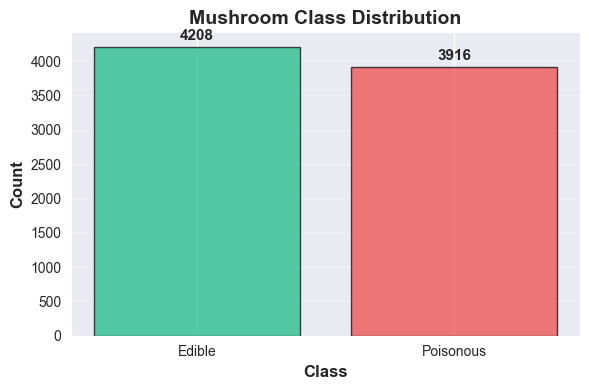

In [16]:
print("TARGET VARIABLE ANALYSIS")

# Class distribution
class_dist = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

print("\nClass Distribution:")
for cls, count in class_dist.items():
    cls_name = "Edible" if cls == 'e' else "Poisonous"
    print(f"{cls_name}: {count} ({class_pct[cls]:.2f}%)")

# Visualizations
plt.figure(figsize=(6, 4))

# Bar plot
class_names = ['Edible' if x == 'e' else 'Poisonous' for x in class_dist.index]
colors = ['#10b981', '#ef4444']
plt.bar(class_names, class_dist.values, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Mushroom Class Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(class_dist.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Target Variable Observations:**
- Nearly balanced dataset (51.8% edible vs 48.2% poisonous)
- No severe class imbalance, suitable for model training without resampling

### Variables analysis

In [17]:
print("VARIABLES ANALYSIS")
features = [col for col in df.columns if col != 'class']

# Analyze each feature
for feature in features:
    print(f"\n{feature.upper()}")
    value_counts = df[feature].value_counts()
    value_pct = df[feature].value_counts(normalize=True) * 100
    print(f"Unique values: {df[feature].nunique()}")
    print(f"\nValue distribution:")
    for val, count in value_counts.items():
        print(f"  {val}: {count} ({value_pct[val]:.2f}%)")

UNIVARIATE ANALYSIS

CAP-SHAPE
Unique values: 6

Value distribution:
  x: 3656 (45.00%)
  f: 3152 (38.80%)
  k: 828 (10.19%)
  b: 452 (5.56%)
  s: 32 (0.39%)
  c: 4 (0.05%)

CAP-SURFACE
Unique values: 4

Value distribution:
  y: 3244 (39.93%)
  s: 2556 (31.46%)
  f: 2320 (28.56%)
  g: 4 (0.05%)

CAP-COLOR
Unique values: 10

Value distribution:
  n: 2284 (28.11%)
  g: 1840 (22.65%)
  e: 1500 (18.46%)
  y: 1072 (13.20%)
  w: 1040 (12.80%)
  b: 168 (2.07%)
  p: 144 (1.77%)
  c: 44 (0.54%)
  u: 16 (0.20%)
  r: 16 (0.20%)

BRUISES
Unique values: 2

Value distribution:
  f: 4748 (58.44%)
  t: 3376 (41.56%)

ODOR
Unique values: 9

Value distribution:
  n: 3528 (43.43%)
  f: 2160 (26.59%)
  s: 576 (7.09%)
  y: 576 (7.09%)
  a: 400 (4.92%)
  l: 400 (4.92%)
  p: 256 (3.15%)
  c: 192 (2.36%)
  m: 36 (0.44%)

GILL-ATTACHMENT
Unique values: 2

Value distribution:
  f: 7914 (97.42%)
  a: 210 (2.58%)

GILL-SPACING
Unique values: 2

Value distribution:
  c: 6812 (83.85%)
  w: 1312 (16.15%)

GILL-SIZE


**Feature Distribution Observations:**

**High Cardinality Features:**
- Gill-color has 12 distinct values
- Cap-color and stalk-color have 9-10 values each

**Dominant Categories:**
- Veil-type has only one value (p: 100%) - can be removed
- Gill-attachment heavily skewed (f: 97.4%)
- Gill-spacing dominated by close spacing (c: 83.9%)
- Ring-number mostly one ring (o: 92.2%)

**Notable Patterns:**
- Cap-shape: x (45%) and f (38.8%) dominate
- Odor: none (43.4%) and foul (26.6%) most common
- Bruises: slightly more without bruises (58.4%)
- Population: varies (v: 49.7%) and several (y: 21.1%) most frequent
- Habitat: diverse with woods (d: 38.8%) and grasses (g: 26.4%) leading

**Rare Categories:**
- Several features have values <1% frequency
- May require grouping for modeling

**Features for visualization**
- Odor
    + Strong predictive potential (43% none, 27% foul)
    + Known key classifier for edible vs poisonous

- Gill-size
    + Binary feature with good distribution (69% broad)
    + Simple clear visualization

- Bruises  
    + Nearly balanced (58% no bruises)
    + Intuitive for identification

- Spore-print-color 
    + Four main colors cover 96% of data
    + Biologically important feature

- Population  
    + Good spread across 6 categories
    + Clear hierarchy in values

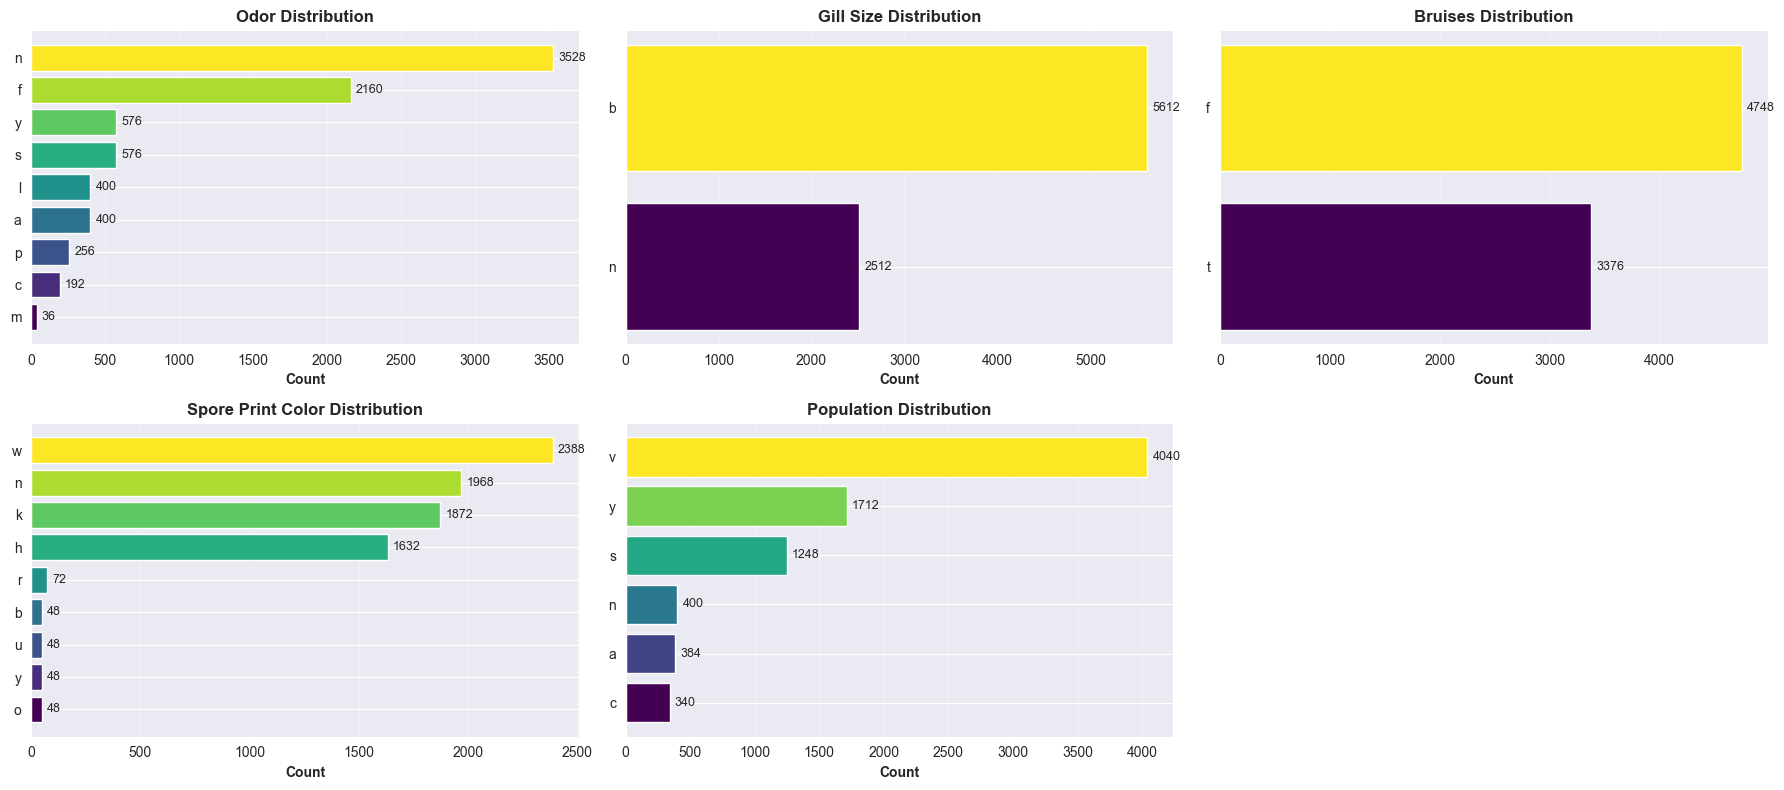

In [25]:
# Visualization 
vis_features = ["odor", "gill-size", "bruises", "spore-print-color", "population"]
# Create subplots
n_features = len(vis_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for idx, feature in enumerate(vis_features):
    if feature in df.columns:
        value_counts = df[feature].value_counts().sort_values(ascending=True)

        axes[idx].barh(range(len(value_counts)), value_counts.values,
                       color=plt.cm.viridis(np.linspace(0, 1, len(value_counts))))
        axes[idx].set_yticks(range(len(value_counts)))
        axes[idx].set_yticklabels(value_counts.index)
        axes[idx].set_xlabel('Count', fontsize=10, fontweight='bold')
        axes[idx].set_title(f'{feature.replace("-", " ").title()} Distribution',
                            fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)

        # Add value labels
        for i, v in enumerate(value_counts.values):
            axes[idx].text(v + max(value_counts.values) * 0.01, i, str(v),
                           va='center', fontsize=9)

    # Hide empty subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')

plt.tight_layout()
plt.show()


### Bivariate Analysis

In [27]:
print("BIVARIATE ANALYSIS - FEATURES VS TARGET")

features = [col for col in df.columns if col != 'class']

# Chi-square test for each feature
chi_square_results = []
for feature in features:
    if df[feature].notna().sum() > 0:
        contingency_table = pd.crosstab(df[feature], df['class'])

        # Skip features with only one category
        if contingency_table.shape[0] == 1:
            continue

        # Perform chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        # Calculate Cramér's V for effect size with safety check
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape) - 1
        if min_dim > 0 and n > 0:
            cramers_v = np.sqrt(chi2 / (n * min_dim))
        else:
            cramers_v = 0

        chi_square_results.append({
            'Feature': feature,
            'Chi-Square': chi2,
            'P-Value': p_value,
            'Cramers V': cramers_v
        })

# Create results dataframe
chi_df = pd.DataFrame(chi_square_results)
chi_df = chi_df.sort_values('Cramers V', ascending=False)

print("\nChi-Square Test Results (sorted by Cramér's V):")
print(chi_df.to_string(index=False))


BIVARIATE ANALYSIS - FEATURES VS TARGET

Chi-Square Test Results (sorted by Cramér's V):
                 Feature  Chi-Square       P-Value  Cramers V
                    odor 7659.726740  0.000000e+00   0.971005
       spore-print-color 4602.033170  0.000000e+00   0.752645
              gill-color 3765.714086  0.000000e+00   0.680830
               ring-type 2956.619278  0.000000e+00   0.603271
stalk-surface-above-ring 2808.286287  0.000000e+00   0.587944
stalk-surface-below-ring 2684.474076  0.000000e+00   0.574837
               gill-size 2366.834257  0.000000e+00   0.539758
  stalk-color-above-ring 2237.898496  0.000000e+00   0.524850
  stalk-color-below-ring 2152.390891  0.000000e+00   0.514725
                 bruises 2041.415647  0.000000e+00   0.501280
              population 1929.740891  0.000000e+00   0.487376
                 habitat 1573.777261  0.000000e+00   0.440136
            gill-spacing  984.143333 5.022978e-216   0.348052
              stalk-root  638.263763 5.1039

**Feature Importance Analysis**

**Strongest Predictors (Cramér's V > 0.5):**
- **Odor** (0.97): Near-perfect predictor - crucial for classification
- **Spore-print-color** (0.75): Very strong relationship
- **Gill-color** (0.68): Highly discriminative
- **Ring-type** (0.60): Strong association
- **Stalk-surface features** (0.57-0.59): Important physical characteristics

**Statistical Significance:**
- All features above show significant relationships (p-value ≈ 0)
- Top 6 features capture most predictive power

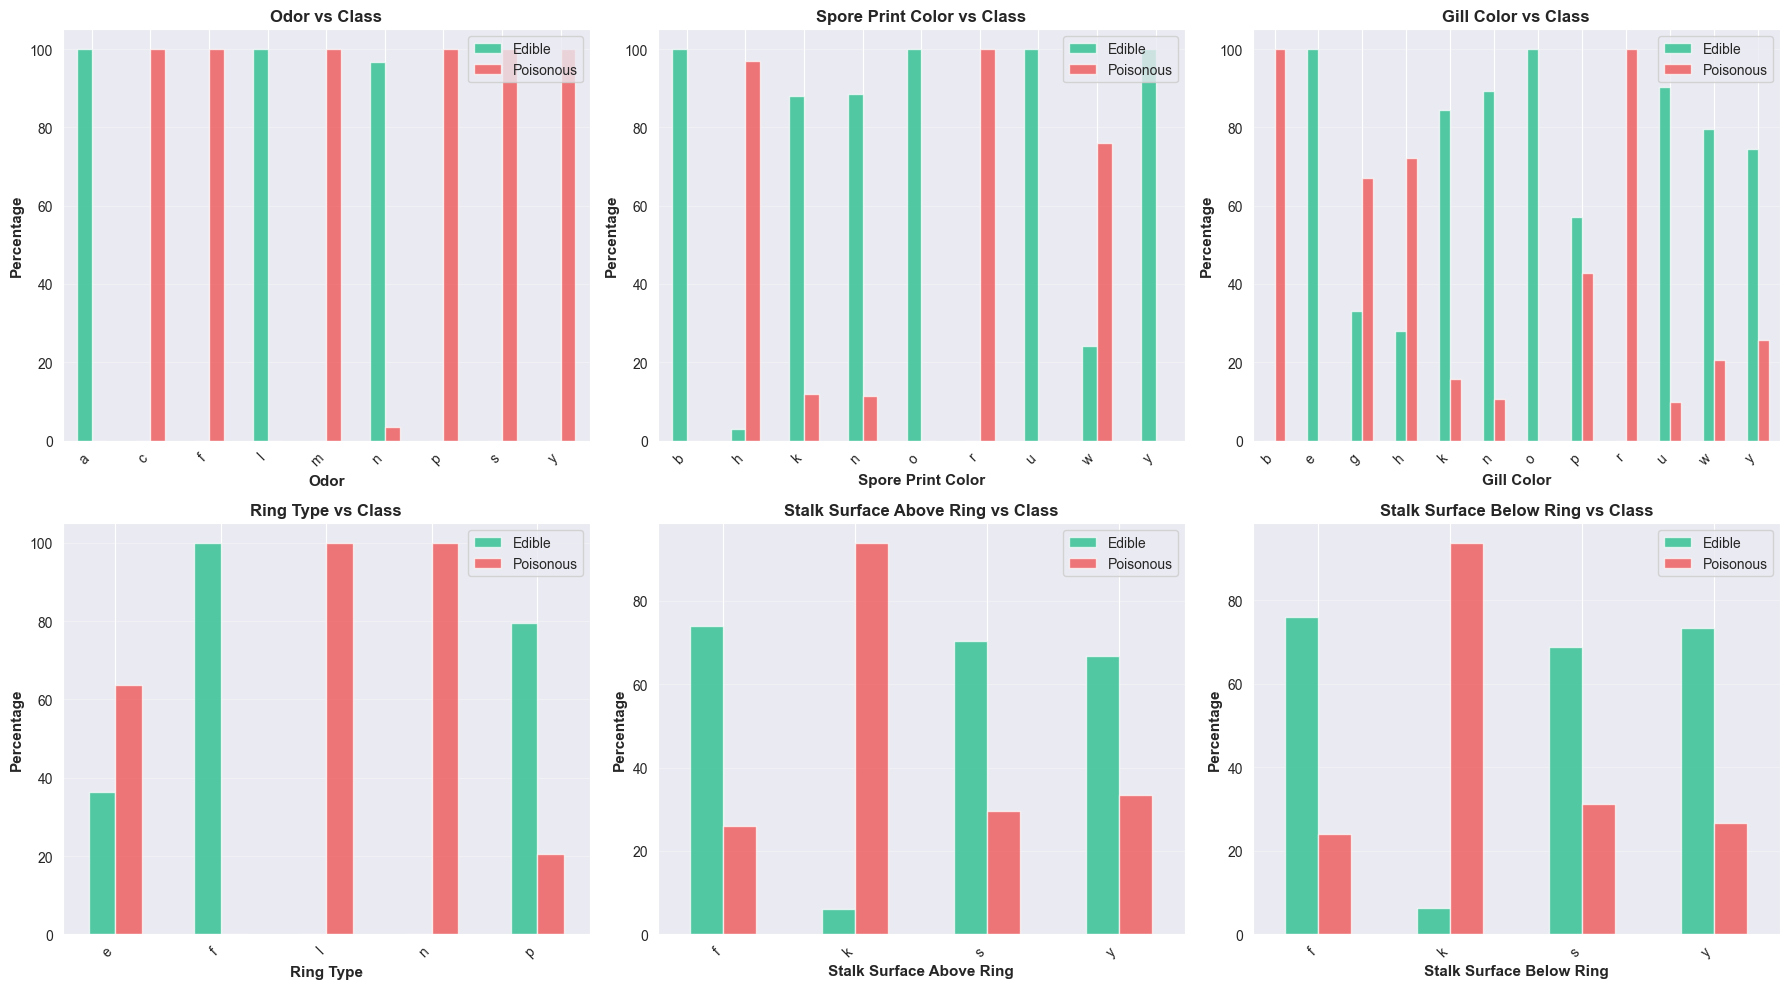

In [28]:
# Get top 6 features
top_features = chi_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    # Create contingency table
    ct = pd.crosstab(df[feature], df['class'], normalize='index') * 100

    ct.plot(kind='bar', ax=axes[idx], color=['#10b981', '#ef4444'], alpha=0.7)
    axes[idx].set_xlabel(feature.replace('-', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Percentage', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature.replace("-", " ").title()} vs Class',
                        fontsize=12, fontweight='bold')
    axes[idx].legend(['Edible', 'Poisonous'], loc='upper right')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Correlation analysis

CORRELATION ANALYSIS


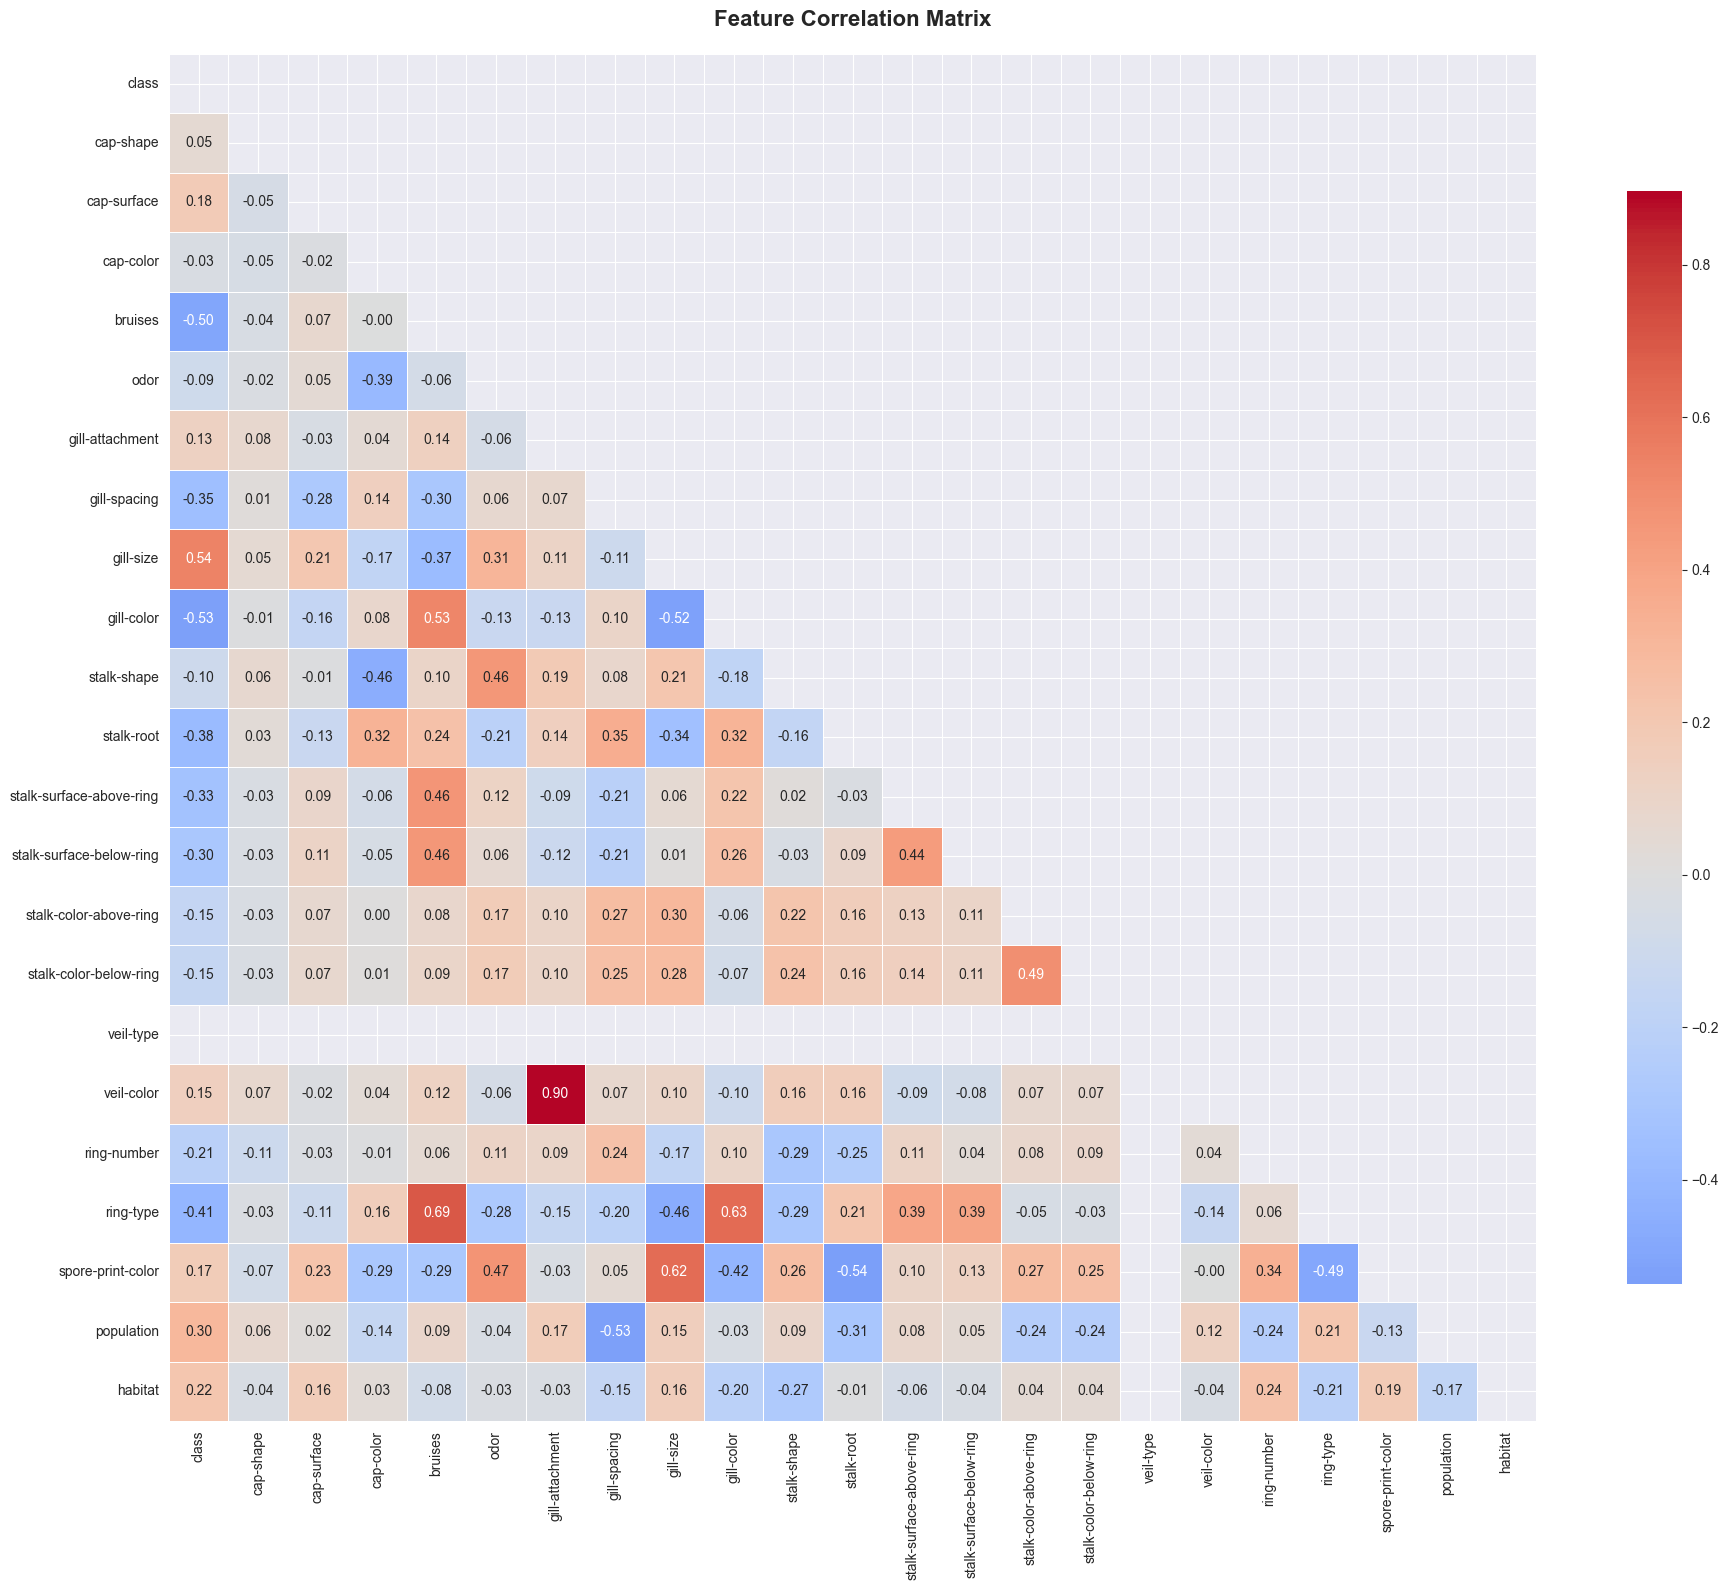


Highly Correlated Feature Pairs (|correlation| > 0.5):
      Feature 1         Feature 2  Correlation
gill-attachment        veil-color     0.897518
        bruises         ring-type     0.692973
     gill-color         ring-type     0.629398
      gill-size spore-print-color     0.622991
          class         gill-size     0.540024
     stalk-root spore-print-color    -0.536996
          class        gill-color    -0.530566
   gill-spacing        population    -0.529253
        bruises        gill-color     0.527120
      gill-size        gill-color    -0.516736
          class           bruises    -0.501530


In [29]:
print("CORRELATION ANALYSIS")

# Label encode all features for correlation
df_encoded = df.copy()
for col in df_encoded.columns:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

# Calculate correlation matrix
corr_matrix = df_encoded.corr()

# Visualize correlation matrix
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

plt.show()

# Find highly correlated features (excluding diagonal)
print("\nHighly Correlated Feature Pairs (|correlation| > 0.5):")

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr)
    high_corr_df = high_corr_df.sort_values('Correlation', ascending=False, key=abs)
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated feature pairs found.")


**Correlation Analysis Observations**

**High Correlations Found:**
- **gill-attachment & veil-color** (0.90): Very strong correlation - likely redundant features
- **bruises & ring-type** (0.69): Strong relationship between physical characteristics
- **gill-color & ring-type** (0.63): Connected mushroom features

**Target Variable Insights:**
- **gill-size** has highest positive correlation with class (0.54)
- **gill-color** and **bruises** show moderate negative correlations
- Confirms chi-square findings about important features

### Key insides and conclusions 

In [30]:
print("KEY INSIGHTS AND RECOMMENDATIONS")

# 1. Class balance
class_balance = df['class'].value_counts()
balance_ratio = min(class_balance) / max(class_balance)

print("\n1. CLASS BALANCE")
print(f"Balance ratio: {balance_ratio:.3f}")
if balance_ratio > 0.8:
    print("Dataset is well-balanced. No resampling needed.")
else:
    print("Dataset is imbalanced.")

# 2. Most predictive features
print("\n2. MOST PREDICTIVE FEATURES")
top_5 = chi_df.head(5)
for idx, row in top_5.iterrows():
    print(f"• {row['Feature']}: Cramér's V = {row['Cramers V']:.3f}")

# 3. Odor analysis (critical feature)
print("\n3. ODOR ANALYSIS (MOST CRITICAL FEATURE)")
odor_class = pd.crosstab(df['odor'], df['class'])
print(odor_class)

# Find perfect predictors
print("\nPerfect Predictors:")
for odor_type in odor_class.index:
    edible = odor_class.loc[odor_type, 'e']
    poisonous = odor_class.loc[odor_type, 'p']
    if edible == 0:
        print(f"  • Odor '{odor_type}': 100% POISONOUS")
    elif poisonous == 0:
        print(f"  • Odor '{odor_type}': 100% EDIBLE")

# 4. Missing values impact
print("\n4. MISSING VALUES")
missing = df.isnull().sum()
if missing.sum() > 0:
    print("Features with missing values:")
    for col, count in missing[missing > 0].items():
        pct = (count / len(df)) * 100
        print(f"  • {col}: {count} ({pct:.2f}%)")
        print(
            f"    Recommendation: {'Impute with mode' if pct < 5 else 'Consider dropping or advanced imputation'}")
else:
    print("No missing values detected.")

# 5. Constant features
print("\n5. CONSTANT/LOW-VARIANCE FEATURES")
for col in df.columns:
    if col != 'class':
        unique = df[col].nunique()
        if unique == 1:
            print(f"  • {col}: Only 1 unique value - REMOVE THIS FEATURE")
        elif unique == 2:
            value_counts = df[col].value_counts()
            ratio = value_counts.iloc[0] / len(df)
            if ratio > 0.95:
                print(f"  • {col}: Very low variance ({ratio:.1%} dominant) - Consider removing")



KEY INSIGHTS AND RECOMMENDATIONS

1. CLASS BALANCE
Balance ratio: 0.931
✓ Dataset is well-balanced. No resampling needed.

2. MOST PREDICTIVE FEATURES
--------------------------------------------------------------------------------
• odor: Cramér's V = 0.971
• spore-print-color: Cramér's V = 0.753
• gill-color: Cramér's V = 0.681
• ring-type: Cramér's V = 0.603
• stalk-surface-above-ring: Cramér's V = 0.588

3. ODOR ANALYSIS (MOST CRITICAL FEATURE)
class     e     p
odor             
a       400     0
c         0   192
f         0  2160
l       400     0
m         0    36
n      3408   120
p         0   256
s         0   576
y         0   576

Perfect Predictors:
  • Odor 'a': 100% EDIBLE
  • Odor 'c': 100% POISONOUS
  • Odor 'f': 100% POISONOUS
  • Odor 'l': 100% EDIBLE
  • Odor 'm': 100% POISONOUS
  • Odor 'p': 100% POISONOUS
  • Odor 's': 100% POISONOUS
  • Odor 'y': 100% POISONOUS

4. MISSING VALUES
Features with missing values:
  • stalk-root: 2480 (30.53%)
    Recommendation: Con

#### Conclusion

##### Key Findings
- **Perfect predictors exist**: Odor alone can classify 64% of mushrooms with 100% accuracy
- **Well-balanced dataset**: No resampling required (51.8% edible vs 48.2% poisonous)
- **Strong feature signals**: Top 5 features (odor, spore-print-color, gill-color, ring-type, stalk-surface) provide excellent predictive power

##### Data Issues
- Remove `veil-type` (constant feature)
- Handle missing values in `stalk-root` (30.5%)
- Possible removing of `gill-attachment` (low variance)

##### Modeling Approach
- **Good to focus on top 5-7 features** for optimal performance
- **Tree-based models** recommended for categorical data
- **High accuracy expected** (>95%) due to strong predictive signals

##### Expected Outcome
Robust mushroom classification model with near-perfect accuracy achievable through proper feature selection and handling of categorical data.